# PEFT LoRA Training Report Notebook

This notebook reads the saved training artifacts for the Phase 2 LoRA runs, then produces:
- a run summary table
- a model comparison matrix
- training and validation curves
- learning-rate and gradient-norm plots
- validation-metric charts
- a checkpoint analysis table

## 1. What the script trained

The training script uses:
- a chat-style prompt
- 4-bit quantized base models
- LoRA adapters
- GroupKFold splitting by `case_num`
- assistant-only loss masking
- a custom validation generation callback

File reference:
- 2_train_slm_ensemble_v2.ipynb
- run_phase2_v2.py

## Training Context & Data Sources

### Data Sources
- **train.csv**: Original training data with pn_num, case_num, feature_num, annotation
- **patient_notes.csv**: Patient notes with pn_num and pn_history
- **features.csv**: Clinical features with case_num, feature_num, feature_text
- **augmented_train.csv**: Augmented training data (optional, used if available)

### Data Split Strategy
- **GroupKFold** with 5 folds, grouped by `case_num`
- **Validation fold**: Fold 4 (20% of cases)
- **Training samples**: ~34,737 (after augmentation and filtering)
- **Validation samples**: ~9,162

### Prompt Format
The training uses a chat-style prompt with:
- **System**: Clinical NLP specialist instructions
- **User**: Patient note + clinical feature
- **Assistant**: JSON output with exact text spans

Example output: `{"spans": ["exact text 1", "exact text 2"]}`


## LoRA Configuration & Training Hyperparameters

### Quantization Settings
- **Method**: 4-bit NF4 (NormalFloat4)
- **Compute dtype**: bfloat16
- **Double quantization**: Enabled
- **Quant storage**: bfloat16

### LoRA Configuration
| Parameter | Value |
|-----------|-------|
| Rank (r) | 16 |
| Alpha | 32 |
| Dropout | 0.05 |
| Target modules | q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj |
| Task type | Causal LM |

### Training Hyperparameters
| Parameter | Value |
|-----------|-------|
| Epochs | 3 |
| Learning rate | 2e-4 |
| LR scheduler | Cosine |
| Warmup ratio | 5% |
| Batch size (per device) | 8 |
| Gradient accumulation | 2 |
| Effective batch size | 16 |
| Max sequence length | 1024 |
| Weight decay | 0.01 |
| Optimizer | adamw_8bit |
| Logging steps | 50 |
| Eval steps | 500 |
| Save steps | 500 |
| Save total limit | 1 |


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

ROOT = Path("adapters")

RUNS = [
    {
        "model_name": "lfm2_.5-1.2B",
        "metrics_path": ROOT / "lfm2_5_1_2b_adapter" / "training_metrics.json",
        "trainer_state_path": ROOT / "lfm2_5_1_2b_adapter" / "checkpoints" / "checkpoint-6516" / "trainer_state.json",
    },
    {
        "model_name": "llama3.1-8b",
        "metrics_path": ROOT / "llama3_1_8b_adapter" / "training_metrics.json",
        "trainer_state_path": ROOT / "llama3_1_8b_adapter" / "checkpoints" / "checkpoint-6516" / "trainer_state.json",
    },
    {
        "model_name": "qwen3.1.7B",
        "metrics_path": ROOT / "qwen3_1_7b_adapter" / "training_metrics.json",
        "trainer_state_path": ROOT / "qwen3_1_7b_adapter" / "checkpoints" / "checkpoint-6516" / "trainer_state.json",
    },
    {
        "model_name": "qwen3-8B",
        "metrics_path": ROOT / "qwen3_8b_adapter" / "training_metrics.json",
        "trainer_state_path": ROOT / "qwen3_8b_adapter" / "checkpoints" / "checkpoint-6516" / "trainer_state.json",
    },
]

def load_json(path: Path) -> Dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def find_first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p.exists():
            return p
    return None

def extract_log_history(metrics: Dict[str, Any], trainer_state: Optional[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if trainer_state and isinstance(trainer_state.get("log_history"), list) and trainer_state["log_history"]:
        return trainer_state["log_history"]
    snapshot = metrics.get("log_history_snapshot", [])
    return snapshot if isinstance(snapshot, list) else []

def as_float(value: Any) -> float:
    try:
        if value is None:
            return np.nan
        return float(value)
    except Exception:
        return np.nan

print("Notebook helpers loaded.")
print("Configured runs:")
for r in RUNS:
    print(f" - {r['model_name']}: {r['metrics_path']}")

Notebook helpers loaded.
Configured runs:
 - lfm2_.5-1.2B: adapters\lfm2_5_1_2b_adapter\training_metrics.json
 - llama3.1-8b: adapters\llama3_1_8b_adapter\training_metrics.json
 - qwen3.1.7B: adapters\qwen3_1_7b_adapter\training_metrics.json
 - qwen3-8B: adapters\qwen3_8b_adapter\training_metrics.json


In [2]:
# Model Registry - size and target modules
import pandas as pd

model_info = pd.DataFrame([
    {"model_name": "lfm2_5_1_2b", "model_id": "LiquidAI/LFM2.5-1.2B-Instruct", "size_category": "1B", "estimated_params": 1.2, "lora_targets": "q_proj, k_proj, v_proj, out_proj, in_proj"},
    {"model_name": "llama3_1_8b", "model_id": "meta-llama/Llama-3.1-8B-Instruct", "size_category": "8B", "estimated_params": 8.0, "lora_targets": "q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj"},
    {"model_name": "qwen3_1_7b", "model_id": "Qwen/Qwen3-1.7B", "size_category": "1B", "estimated_params": 1.7, "lora_targets": "q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj"},
    {"model_name": "qwen3_8b", "model_id": "Qwen/Qwen3-8B", "size_category": "8B", "estimated_params": 8.0, "lora_targets": "q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj"},
])

print("Model Registry:")
display(model_info)

Model Registry:


,model_name,model_id,size_category,estimated_params,lora_targets
0,lfm2_5_1_2b,LiquidAI/LFM2.5-1.2B-Instruct,1B,1.2,"q_proj, k_proj, v_proj, out_proj, in_proj"
1,llama3_1_8b,meta-llama/Llama-3.1-8B-Instruct,8B,8.0,"q_proj, k_proj, v_proj, o_proj, gate_proj, up_..."
2,qwen3_1_7b,Qwen/Qwen3-1.7B,1B,1.7,"q_proj, k_proj, v_proj, o_proj, gate_proj, up_..."
3,qwen3_8b,Qwen/Qwen3-8B,8B,8.0,"q_proj, k_proj, v_proj, o_proj, gate_proj, up_..."


## 2. Load the saved artifacts

This section checks whether the expected JSON files exist and then loads:
- `training_metrics.json`
- `trainer_state.json`

If a full trainer state is unavailable, the notebook falls back to the `log_history_snapshot` stored in `training_metrics.json`.

In [3]:
runs_data: List[Dict[str, Any]] = []

for spec in RUNS:
    metrics = load_json(spec["metrics_path"])
    trainer_state = load_json(spec["trainer_state_path"]) if spec["trainer_state_path"].exists() else None
    history = extract_log_history(metrics, trainer_state)

    runs_data.append({
        "model_name": spec["model_name"],
        "metrics_path": str(spec["metrics_path"]),
        "trainer_state_path": str(spec["trainer_state_path"]) if spec["trainer_state_path"].exists() else None,
        "metrics": metrics,
        "trainer_state": trainer_state,
        "history": history,
    })

len(runs_data), [r["model_name"] for r in runs_data]

(4, ['lfm2_.5-1.2B', 'llama3.1-8b', 'qwen3.1.7B', 'qwen3-8B'])

## 3. Build summary tables

The tables below answer the first reporting question:
- what was trained
- how much data was used
- what the final metrics were
- which checkpoint looked best

In [4]:
summary_rows = []
checkpoint_rows = []

for run in runs_data:
    m = run["metrics"]
    h = pd.DataFrame(run["history"])

    # Safely select columns that exist in the DataFrame
    eval_col_candidates = ["step", "epoch", "eval_loss", "eval_runtime", "eval_samples_per_second", "eval_steps_per_second"]
    eval_cols = [col for col in eval_col_candidates if col in h.columns]
    eval_df = h[eval_cols].copy() if eval_cols else pd.DataFrame()
    if not h.empty and "eval_loss" in h.columns:
        eval_rows = h.loc[h["eval_loss"].notna(), ["step", "epoch", "eval_loss"]].copy()
    else:
        eval_rows = pd.DataFrame(columns=["step", "epoch", "eval_loss"])

    best_eval_step = None
    best_eval_loss = None
    if not eval_rows.empty:
        best_idx = eval_rows["eval_loss"].astype(float).idxmin()
        best_eval_step = int(eval_rows.loc[best_idx, "step"])
        best_eval_loss = float(eval_rows.loc[best_idx, "eval_loss"])

    first_eval_loss = float(eval_rows.iloc[0]["eval_loss"]) if not eval_rows.empty else np.nan
    final_eval_loss = float(eval_rows.iloc[-1]["eval_loss"]) if not eval_rows.empty else np.nan
    final_train_loss = float(m.get("training_loss", np.nan))
    gap_final = final_eval_loss - final_train_loss if pd.notna(final_eval_loss) and pd.notna(final_train_loss) else np.nan

    summary_rows.append({
        "model_name": run["model_name"],
        "model_id": m.get("model_id"),
        "train_samples": m.get("train_samples"),
        "val_samples": m.get("val_samples"),
        "global_step": m.get("global_step"),
        "final_training_loss": final_train_loss,
        "final_eval_loss": final_eval_loss,
        "best_eval_loss": best_eval_loss,
        "best_eval_step": best_eval_step,
        "val_gen_n": m.get("val_gen_n"),
        "val_jsonish_rate": m.get("val_jsonish_rate"),
        "val_contained_rate": m.get("val_contained_rate"),
        "val_empty_accuracy": m.get("val_empty_accuracy"),
        "val_char_f1": m.get("val_char_f1"),
        "train_val_gap_at_end": gap_final,
        "num_log_rows": len(h),
        "num_eval_rows": int(eval_rows.shape[0]),
        "trainer_state_source": "full trainer_state" if run["trainer_state"] else "training_metrics snapshot",
    })

    if not eval_rows.empty:
        for _, row in eval_rows.iterrows():
            checkpoint_rows.append({
                "model_name": run["model_name"],
                "step": int(row["step"]),
                "epoch": float(row["epoch"]),
                "eval_loss": float(row["eval_loss"]),
            })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("model_name").reset_index(drop=True)

checkpoint_df = pd.DataFrame(checkpoint_rows).sort_values(["model_name", "eval_loss"]).reset_index(drop=True)

summary_df

,model_name,model_id,train_samples,val_samples,global_step,final_training_loss,final_eval_loss,best_eval_loss,best_eval_step,val_gen_n,val_jsonish_rate,val_contained_rate,val_empty_accuracy,val_char_f1,train_val_gap_at_end,num_log_rows,num_eval_rows,trainer_state_source
0,lfm2_.5-1.2B,LiquidAI/LFM2.5-1.2B-Instruct,34737,9162,6516,0.116926,0.231591,0.193204,2000,128,1.0,0.921875,0.812500,0.512378,0.114665,144,14,full trainer_state
1,llama3.1-8b,meta-llama/Llama-3.1-8B-Instruct,34737,9162,6516,0.110712,0.247132,0.204352,2000,128,1.0,0.992188,0.890625,0.629213,0.136420,144,14,full trainer_state
2,qwen3-8B,Qwen/Qwen3-8B,34737,9162,6516,0.092396,0.217111,0.162775,2000,128,1.0,0.984375,0.906250,0.604596,0.124715,144,14,full trainer_state
3,qwen3.1.7B,Qwen/Qwen3-1.7B,34737,9162,6516,0.110548,0.229205,0.183285,2000,128,1.0,0.968750,0.906250,0.582444,0.118657,144,14,full trainer_state


In [5]:
# Enhance summary with model size info
if 'summary_df' in locals() and 'model_info' in locals():
    param_map = {row["model_name"]: row["estimated_params"] for _, row in model_info.iterrows()}
    category_map = {row["model_name"]: row["size_category"] for _, row in model_info.iterrows()}
    
    summary_df["estimated_params_B"] = summary_df["model_name"].map(param_map)
    summary_df["size_category"] = summary_df["model_name"].map(category_map)
    summary_df["char_f1_per_B"] = summary_df["val_char_f1"] / summary_df["estimated_params_B"]
    
    display_cols_extended = [
        "model_name", "size_category", "train_samples", "val_samples", "global_step",
        "final_training_loss", "best_eval_loss", "best_eval_step",
        "val_jsonish_rate", "val_contained_rate", "val_empty_accuracy", "val_char_f1",
        "char_f1_per_B", "train_val_gap_at_end"
    ]
    
    print("Enhanced Summary Table:")
    display(summary_df[display_cols_extended].sort_values("val_char_f1", ascending=False))
else:
    print("summary_df or model_info not found")

Enhanced Summary Table:


,model_name,size_category,train_samples,val_samples,global_step,final_training_loss,best_eval_loss,best_eval_step,val_jsonish_rate,val_contained_rate,val_empty_accuracy,val_char_f1,char_f1_per_B,train_val_gap_at_end
1,llama3.1-8b,NaN,34737,9162,6516,0.110712,0.204352,2000,1.0,0.992188,0.890625,0.629213,NaN,0.136420
2,qwen3-8B,NaN,34737,9162,6516,0.092396,0.162775,2000,1.0,0.984375,0.906250,0.604596,NaN,0.124715
3,qwen3.1.7B,NaN,34737,9162,6516,0.110548,0.183285,2000,1.0,0.968750,0.906250,0.582444,NaN,0.118657
0,lfm2_.5-1.2B,NaN,34737,9162,6516,0.116926,0.193204,2000,1.0,0.921875,0.812500,0.512378,NaN,0.114665


In [6]:
# Readable display format
display_cols = [
    "model_name", "train_samples", "val_samples", "global_step",
    "final_training_loss", "final_eval_loss", "best_eval_loss", "best_eval_step",
    "val_jsonish_rate", "val_contained_rate", "val_empty_accuracy", "val_char_f1",
    "train_val_gap_at_end", "num_eval_rows"
]

display(summary_df[display_cols])

,model_name,train_samples,val_samples,global_step,final_training_loss,final_eval_loss,best_eval_loss,best_eval_step,val_jsonish_rate,val_contained_rate,val_empty_accuracy,val_char_f1,train_val_gap_at_end,num_eval_rows
0,lfm2_.5-1.2B,34737,9162,6516,0.116926,0.231591,0.193204,2000,1.0,0.921875,0.812500,0.512378,0.114665,14
1,llama3.1-8b,34737,9162,6516,0.110712,0.247132,0.204352,2000,1.0,0.992188,0.890625,0.629213,0.136420,14
2,qwen3-8B,34737,9162,6516,0.092396,0.217111,0.162775,2000,1.0,0.984375,0.906250,0.604596,0.124715,14
3,qwen3.1.7B,34737,9162,6516,0.110548,0.229205,0.183285,2000,1.0,0.968750,0.906250,0.582444,0.118657,14


## 4. Validation checkpoint table

In [7]:
best_checkpoint_table = (
    checkpoint_df
    .sort_values(["model_name", "eval_loss"], ascending=[True, True])
    .groupby("model_name", as_index=False)
    .first()[["model_name", "step", "epoch", "eval_loss"]]
    .rename(columns={"step": "best_eval_step", "epoch": "best_eval_epoch"})
)

display(best_checkpoint_table)

,model_name,best_eval_step,best_eval_epoch,eval_loss
0,lfm2_.5-1.2B,2000,0.921022,0.193204
1,llama3.1-8b,2000,0.921022,0.204352
2,qwen3-8B,2000,0.921022,0.162775
3,qwen3.1.7B,2000,0.921022,0.183285


## 5. Model comparison matrix

This matrix gives a compact cross-model view.

Interpretation:
- lower loss is better
- higher validation metrics are better
- the heatmap uses min-max scaling only for visualization
- the raw table above remains the source of truth

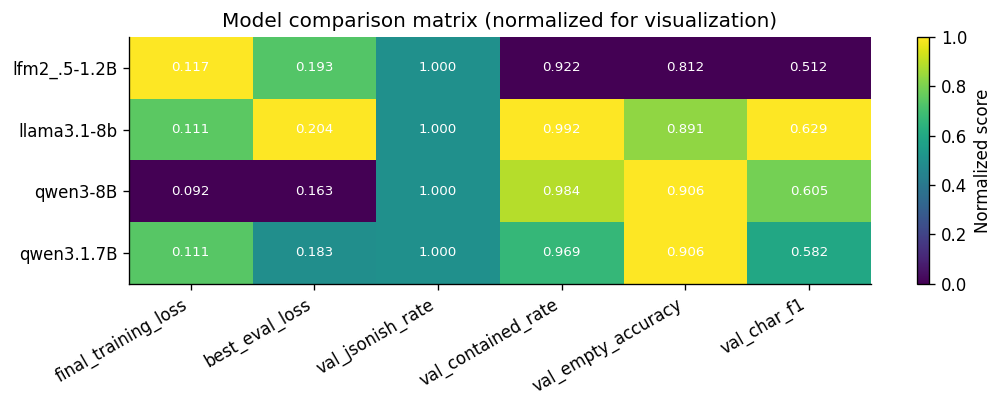

In [8]:
matrix_cols = [
    "final_training_loss",
    "best_eval_loss",
    "val_jsonish_rate",
    "val_contained_rate",
    "val_empty_accuracy",
    "val_char_f1",
]

matrix_df = summary_df.set_index("model_name")[matrix_cols].copy()

# Normalize only for visualization.
viz_df = matrix_df.copy()
for col in viz_df.columns:
    col_min = viz_df[col].min()
    col_max = viz_df[col].max()
    if pd.isna(col_min) or pd.isna(col_max) or col_max == col_min:
        viz_df[col] = 0.5
    else:
        viz_df[col] = (viz_df[col] - col_min) / (col_max - col_min)

fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(viz_df.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(np.arange(viz_df.shape[1]))
ax.set_xticklabels(viz_df.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(viz_df.shape[0]))
ax.set_yticklabels(viz_df.index)
ax.set_title("Model comparison matrix (normalized for visualization)")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Normalized score")
for i in range(viz_df.shape[0]):
    for j in range(viz_df.shape[1]):
        ax.text(j, i, f"{matrix_df.iloc[i, j]:.3f}", ha="center", va="center", color="white", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Training dynamics

These plots show whether optimization behaved normally:
- training loss should fall
- validation loss should improve and then usually flatten
- learning rate should follow the scheduler
- gradient norm should not explode

In [9]:
def history_to_frame(run: Dict[str, Any]) -> pd.DataFrame:
    h = pd.DataFrame(run["history"]).copy()
    if h.empty:
        return h
    h["model_name"] = run["model_name"]
    for col in ["step", "epoch", "loss", "eval_loss", "learning_rate", "grad_norm", "eval_runtime", "eval_samples_per_second", "eval_steps_per_second"]:
        if col in h.columns:
            h[col] = pd.to_numeric(h[col], errors="coerce")
    return h

history_df = pd.concat([history_to_frame(r) for r in runs_data], ignore_index=True, sort=False)

train_df = history_df.loc[history_df["loss"].notna(), ["model_name", "step", "epoch", "loss"]].copy()
eval_df = history_df.loc[history_df["eval_loss"].notna(), ["model_name", "step", "epoch", "eval_loss", "eval_runtime", "eval_samples_per_second", "eval_steps_per_second"]].copy()
lr_df = history_df.loc[history_df["learning_rate"].notna(), ["model_name", "step", "epoch", "learning_rate"]].copy()
grad_df = history_df.loc[history_df["grad_norm"].notna(), ["model_name", "step", "epoch", "grad_norm"]].copy()

print("Training rows:", len(train_df))
print("Eval rows:", len(eval_df))
print("LR rows:", len(lr_df))
print("Grad rows:", len(grad_df))

Training rows: 520
Eval rows: 56
LR rows: 520
Grad rows: 520


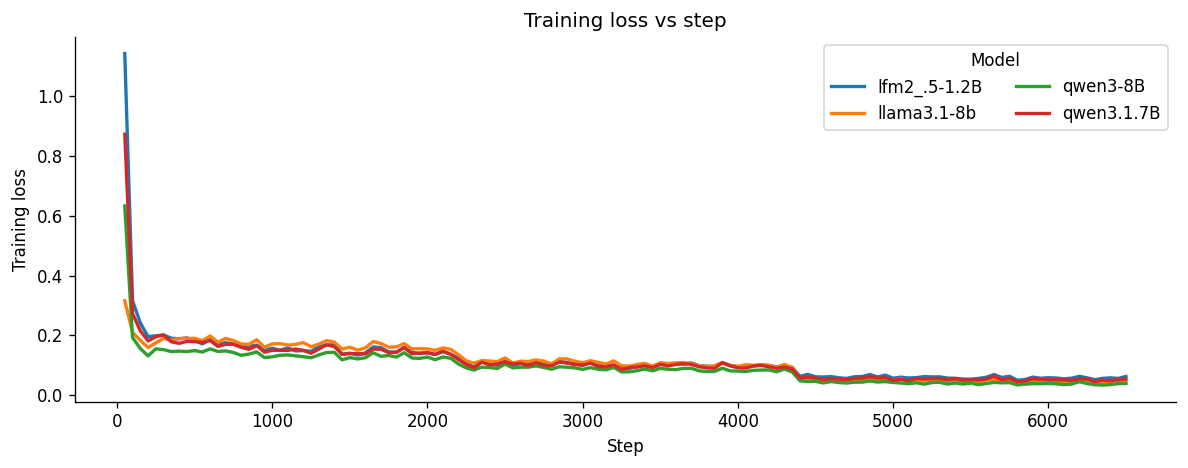

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
for model_name, g in train_df.groupby("model_name"):
    ax.plot(g["step"], g["loss"], label=model_name, linewidth=2)
ax.set_title("Training loss vs step")
ax.set_xlabel("Step")
ax.set_ylabel("Training loss")
ax.legend(title="Model", ncol=2)
plt.tight_layout()
plt.show()

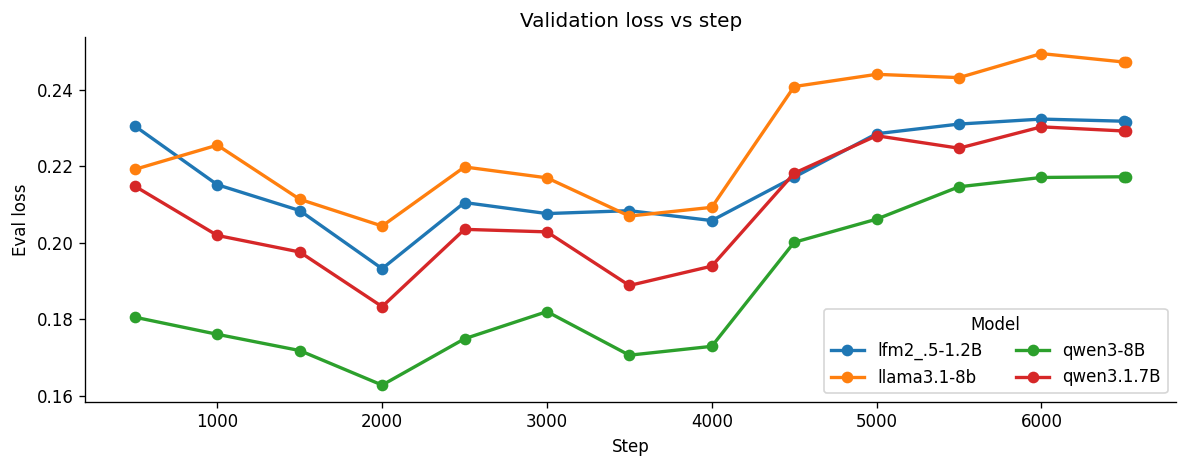

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
for model_name, g in eval_df.groupby("model_name"):
    ax.plot(g["step"], g["eval_loss"], marker="o", label=model_name, linewidth=2)
ax.set_title("Validation loss vs step")
ax.set_xlabel("Step")
ax.set_ylabel("Eval loss")
ax.legend(title="Model", ncol=2)
plt.tight_layout()
plt.show()

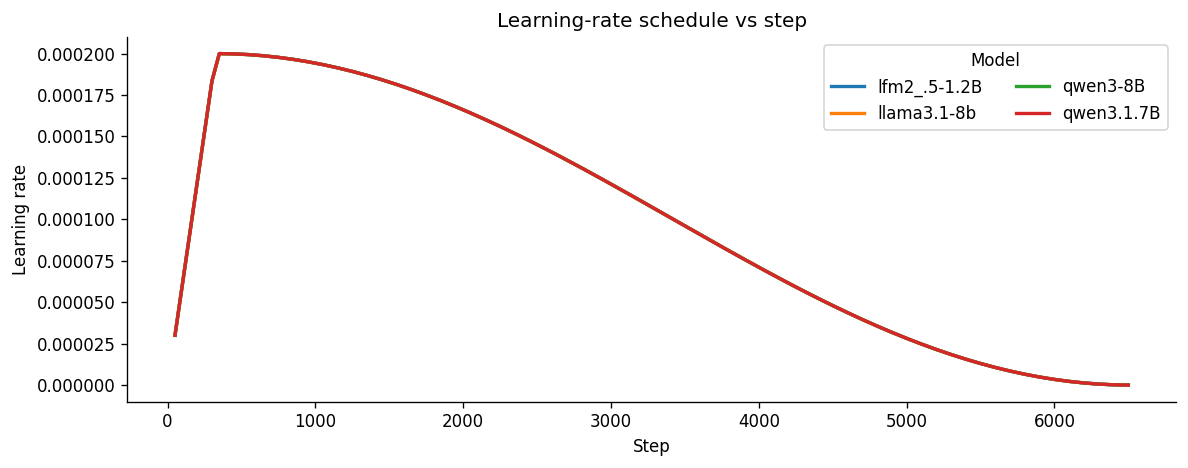

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
for model_name, g in lr_df.groupby("model_name"):
    ax.plot(g["step"], g["learning_rate"], label=model_name, linewidth=2)
ax.set_title("Learning-rate schedule vs step")
ax.set_xlabel("Step")
ax.set_ylabel("Learning rate")
ax.legend(title="Model", ncol=2)
plt.tight_layout()
plt.show()

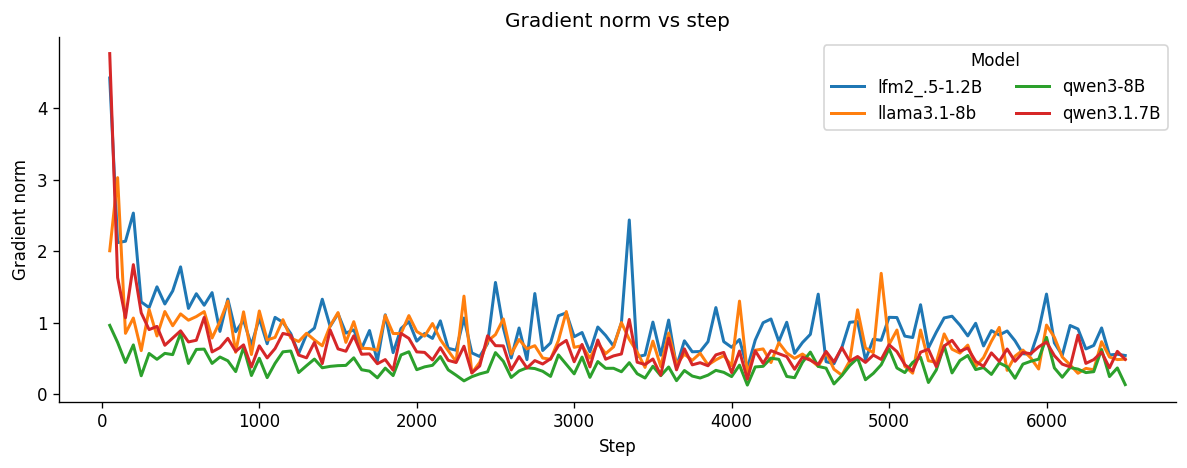

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
for model_name, g in grad_df.groupby("model_name"):
    ax.plot(g["step"], g["grad_norm"], label=model_name, linewidth=1.8)
ax.set_title("Gradient norm vs step")
ax.set_xlabel("Step")
ax.set_ylabel("Gradient norm")
ax.legend(title="Model", ncol=2)
plt.tight_layout()
plt.show()

## 7. Final validation metrics

These metrics come from the custom generation callback and are the most important task-level numbers for this assignment:
- `val_jsonish_rate`: did the model return valid-looking JSON?
- `val_contained_rate`: were predicted spans found in the note?
- `val_empty_accuracy`: did the model handle empty targets correctly?
- `val_char_f1`: character-level overlap with the ground truth spans

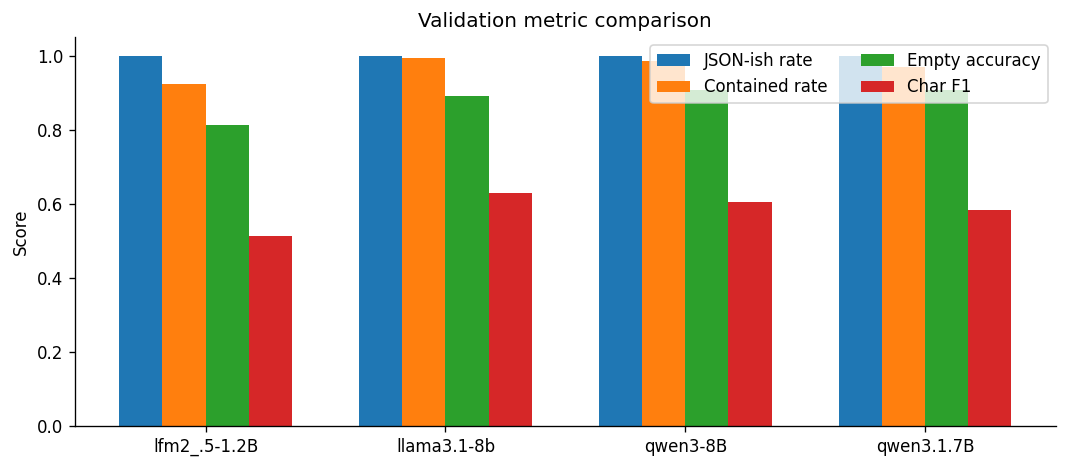

In [14]:
metric_cols = ["val_jsonish_rate", "val_contained_rate", "val_empty_accuracy", "val_char_f1"]
metric_labels = {
    "val_jsonish_rate": "JSON-ish rate",
    "val_contained_rate": "Contained rate",
    "val_empty_accuracy": "Empty accuracy",
    "val_char_f1": "Char F1",
}

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(summary_df))
width = 0.18

for i, col in enumerate(metric_cols):
    ax.bar(x + (i - 1.5) * width, summary_df[col].values, width=width, label=metric_labels[col])

ax.set_xticks(x)
ax.set_xticklabels(summary_df["model_name"], rotation=0)
ax.set_ylim(0, 1.05)
ax.set_title("Validation metric comparison")
ax.set_ylabel("Score")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

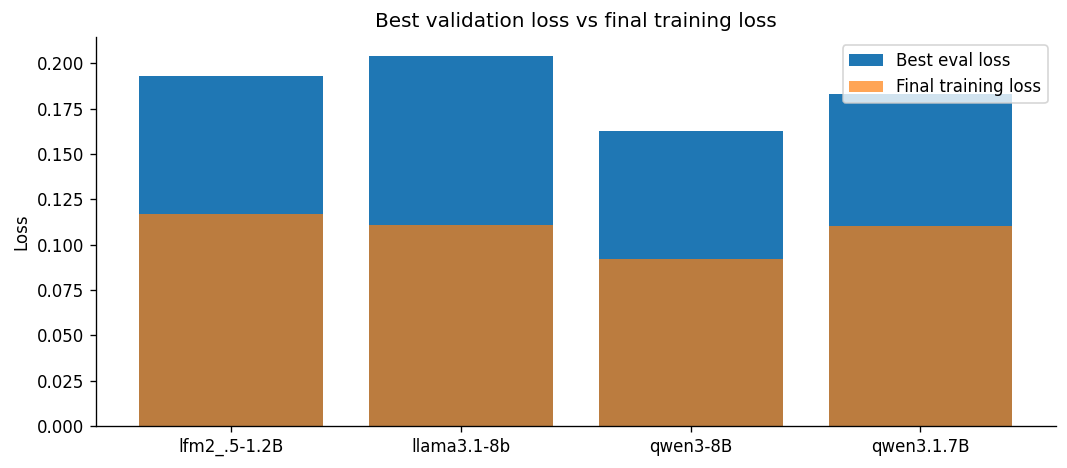

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(summary_df["model_name"], summary_df["best_eval_loss"], label="Best eval loss")
ax.bar(summary_df["model_name"], summary_df["final_training_loss"], alpha=0.7, label="Final training loss")
ax.set_title("Best validation loss vs final training loss")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Checkpoint analysis

This table shows the best validation point per model and the train-validation gap at the end of training.

Use this section in the report to explain:
- whether the final checkpoint was the best one
- whether validation continued improving late in training
- whether the model is starting to overfit

In [16]:
analysis_cols = [
    "model_name",
    "final_training_loss",
    "best_eval_loss",
    "best_eval_step",
    "final_eval_loss",
    "train_val_gap_at_end",
    "val_jsonish_rate",
    "val_contained_rate",
    "val_empty_accuracy",
    "val_char_f1",
]
display(summary_df[analysis_cols].sort_values("best_eval_loss"))

,model_name,final_training_loss,best_eval_loss,best_eval_step,final_eval_loss,train_val_gap_at_end,val_jsonish_rate,val_contained_rate,val_empty_accuracy,val_char_f1
2,qwen3-8B,0.092396,0.162775,2000,0.217111,0.124715,1.0,0.984375,0.906250,0.604596
3,qwen3.1.7B,0.110548,0.183285,2000,0.229205,0.118657,1.0,0.968750,0.906250,0.582444
0,lfm2_.5-1.2B,0.116926,0.193204,2000,0.231591,0.114665,1.0,0.921875,0.812500,0.512378
1,llama3.1-8b,0.110712,0.204352,2000,0.247132,0.136420,1.0,0.992188,0.890625,0.629213


## Improved Visualization 1: Training vs Validation Loss (Faceted)

Overlaying training and validation loss on the same plot for each model.
This makes it easy to spot overfitting (val loss increasing while train loss decreases).

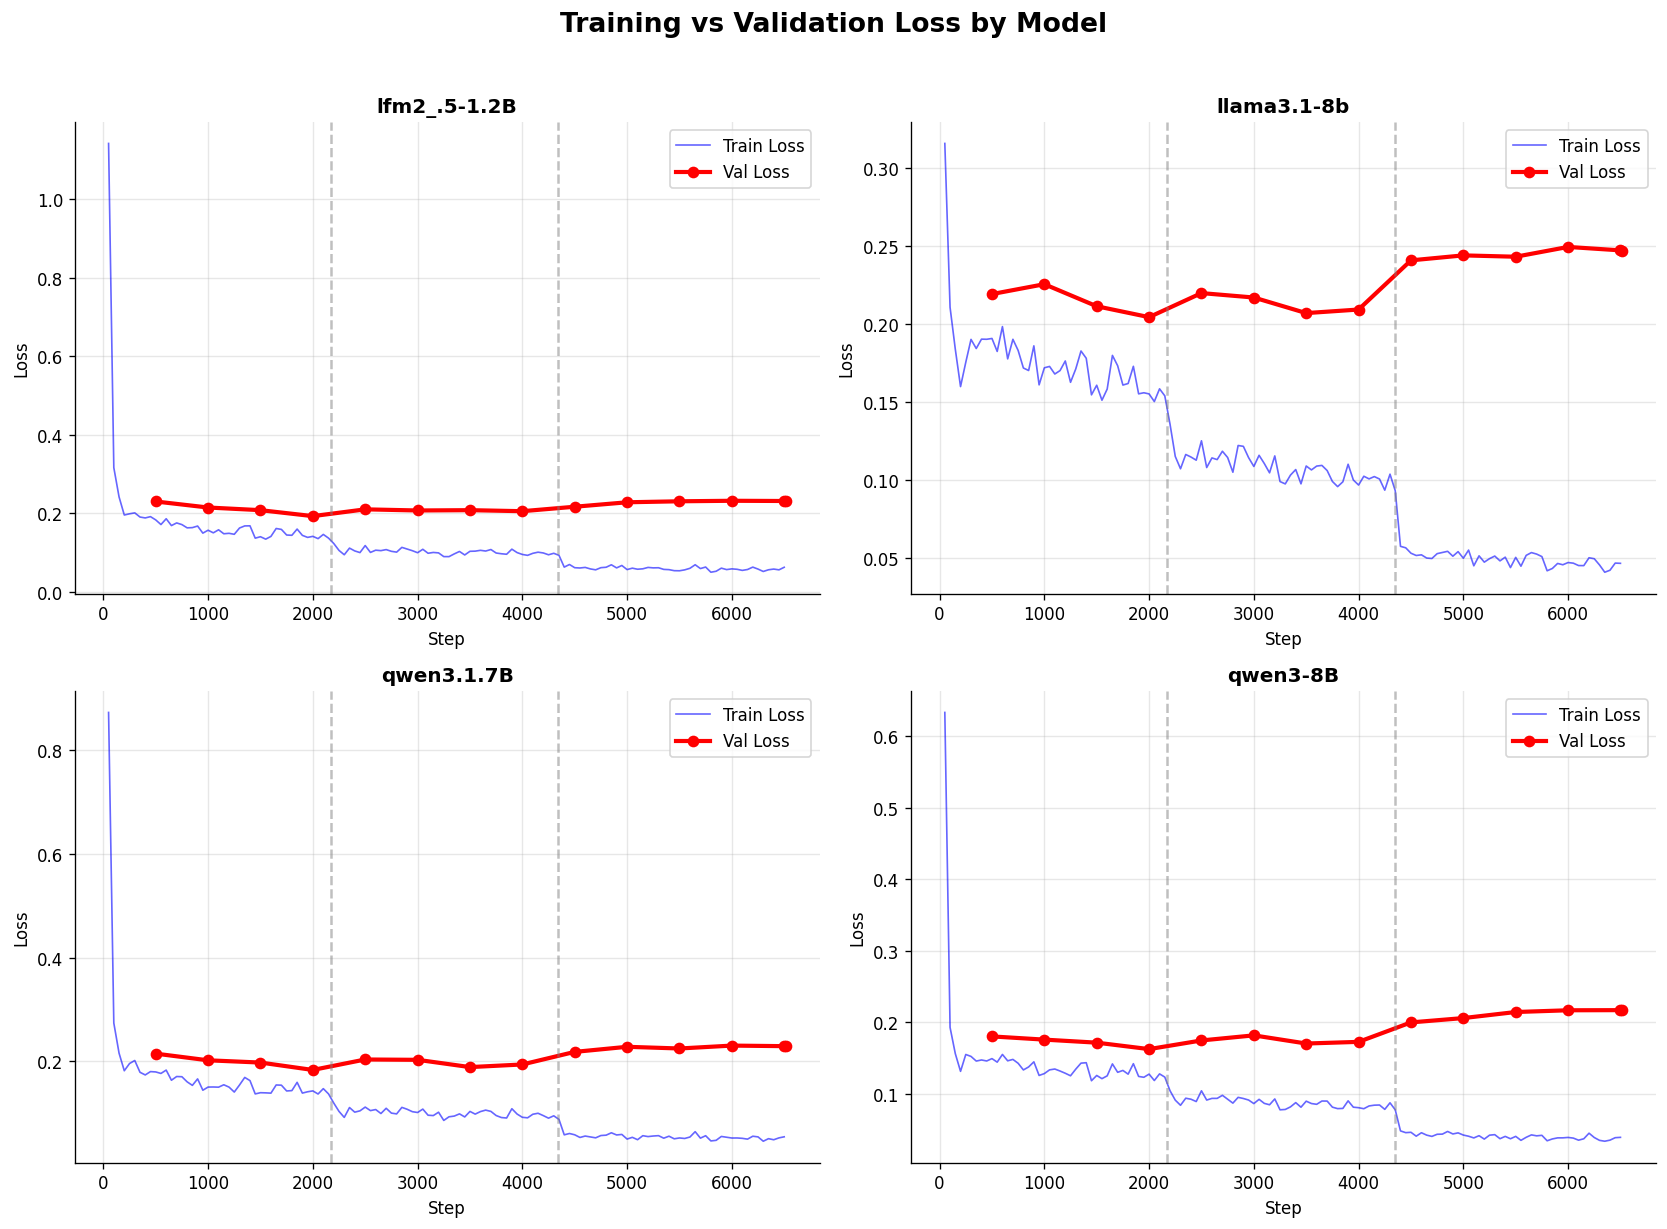

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def create_faceted_loss_plot(runs_data):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, run in enumerate(runs_data):
        ax = axes[idx]
        h = pd.DataFrame(run["history"])
        
        if h.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(run['model_name'])
            continue
        
        # Plot training loss
        train_mask = h['loss'].notna()
        if train_mask.any():
            train_data = h[train_mask]
            ax.plot(train_data['step'], train_data['loss'], 'b-', alpha=0.6, linewidth=1, label='Train Loss')
        
        # Plot eval loss
        eval_mask = h['eval_loss'].notna()
        if eval_mask.any():
            eval_data = h[eval_mask]
            ax.plot(eval_data['step'], eval_data['eval_loss'], 'r-', linewidth=2.5, marker='o', markersize=6, label='Val Loss')
        
        # Add epoch boundaries (assuming 3 epochs)
        max_step = h['step'].max() if not h.empty else 0
        for epoch in [1, 2]:
            step = max_step * epoch / 3
            ax.axvline(x=step, color='gray', linestyle='--', alpha=0.5)
        
        ax.set_title(run['model_name'], fontsize=12, fontweight='bold')
        ax.set_xlabel('Step')
        ax.set_ylabel('Loss')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Training vs Validation Loss by Model', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

if 'runs_data' in locals():
    create_faceted_loss_plot(runs_data)
else:
    print('runs_data not found')

## Improved Visualization 2: Performance vs Efficiency

Scatter plot showing the trade-off between validation performance (char_f1) and inference speed.
Bubble size represents model size. This helps identify the best efficiency-performance frontier.

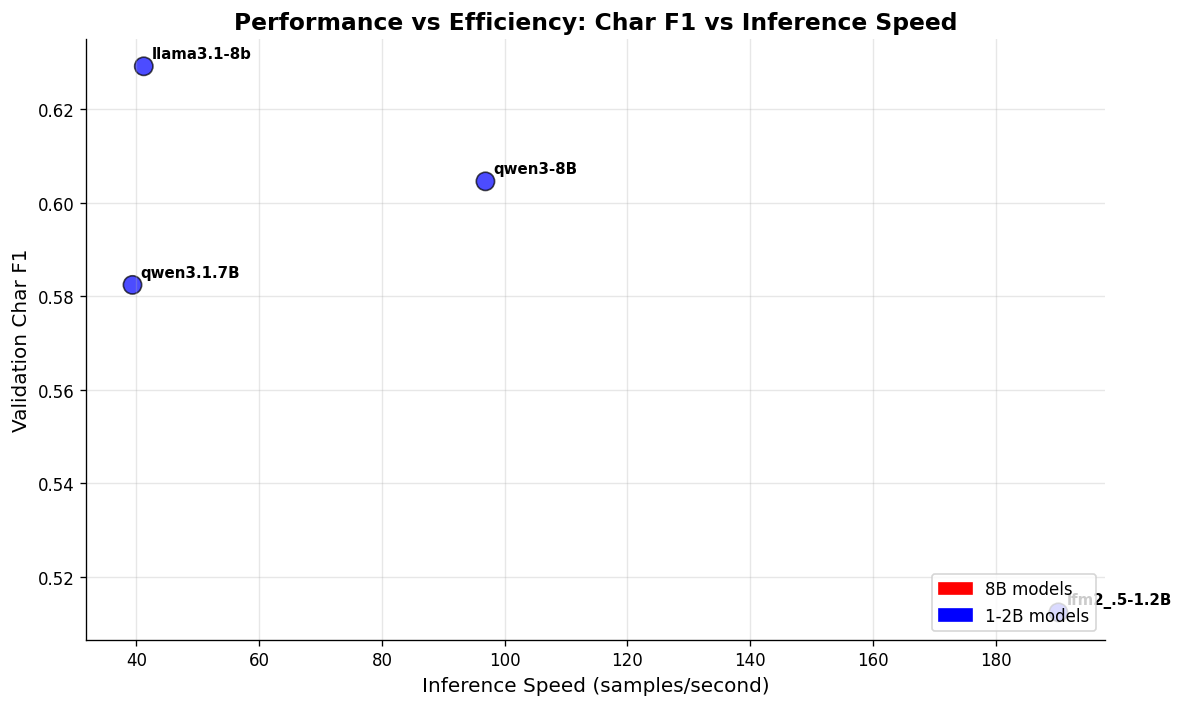

In [18]:
def create_performance_efficiency_plot(summary_df, runs_data):
    # Check if required columns exist
    if 'size_category' not in summary_df.columns:
        print('size_category not in summary_df, adding it...')
        if 'model_info' in locals():
            category_map = {row['model_name']: row['size_category'] for _, row in model_info.iterrows()}
            summary_df['size_category'] = summary_df['model_name'].map(category_map)
        else:
            summary_df['size_category'] = 'Unknown'
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Get eval samples per second from the last eval entry
    speed_data = []
    for run in runs_data:
        h = pd.DataFrame(run['history'])
        eval_rows = h[h['eval_loss'].notna()]
        if not eval_rows.empty:
            last_eval = eval_rows.iloc[-1]
            speed = last_eval.get('eval_samples_per_second', 0)
        else:
            speed = 0
        speed_data.append(speed)
    
    colors = ['red' if cat == '8B' else 'blue' for cat in summary_df['size_category']]
    sizes = [200 if cat == '8B' else 120 for cat in summary_df['size_category']]
    
    ax.scatter(speed_data, summary_df['val_char_f1'], 
              s=sizes, c=colors, alpha=0.7, edgecolors='black')
    
    # Annotate points
    for i, row in summary_df.iterrows():
        ax.annotate(row['model_name'], 
                   (speed_data[i], row['val_char_f1']),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, fontweight='bold')
    
    # Add legend for size categories
    import matplotlib.patches as mpatches
    red_patch = mpatches.Patch(color='red', label='8B models')
    blue_patch = mpatches.Patch(color='blue', label='1-2B models')
    ax.legend(handles=[red_patch, blue_patch], loc='lower right')
    
    ax.set_xlabel('Inference Speed (samples/second)', fontsize=12)
    ax.set_ylabel('Validation Char F1', fontsize=12)
    ax.set_title('Performance vs Efficiency: Char F1 vs Inference Speed', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if 'summary_df' in locals() and 'runs_data' in locals():
    create_performance_efficiency_plot(summary_df, runs_data)
else:
    print('summary_df or runs_data not found')

## Improved Visualization 3: Validation Metrics Radar Chart

Radar chart comparing the key validation metrics across models.
Excludes jsonish_rate (all 1.0) as it's not discriminating.

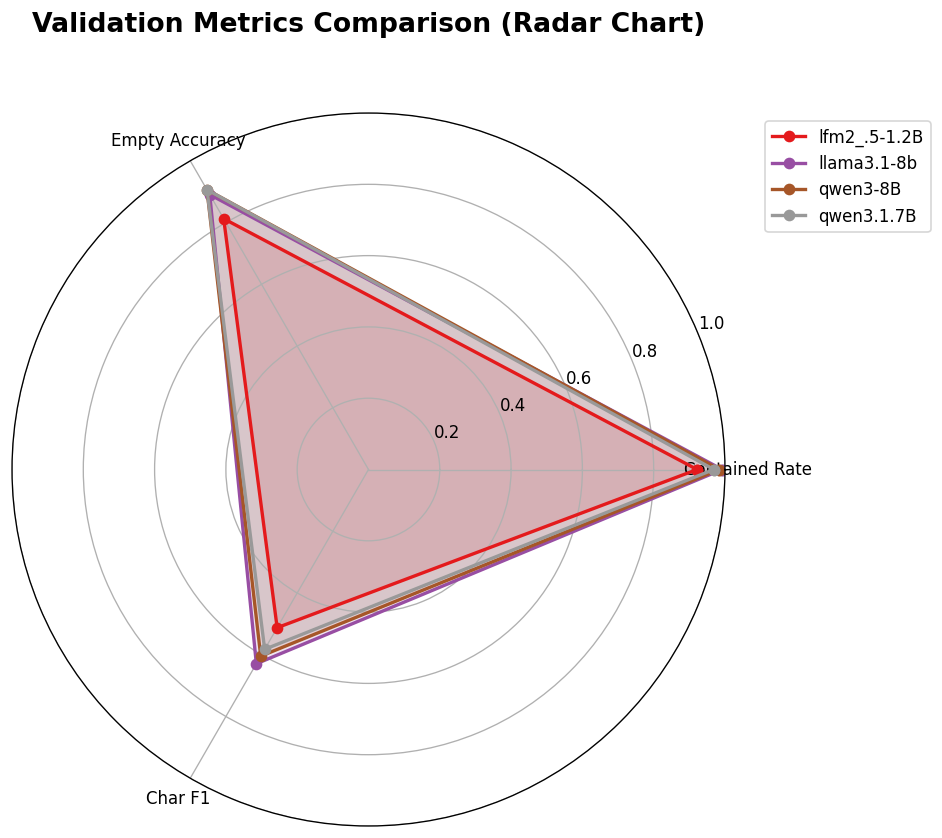

In [19]:
def create_radar_chart(summary_df):
    from math import pi
    
    # Metrics to plot (excluding jsonish_rate which is 1.0 for all)
    metrics = ['val_contained_rate', 'val_empty_accuracy', 'val_char_f1']
    
    # Number of variables
    N = len(metrics)
    
    # Compute angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Close the polygon
    
    # Initialize the spider plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    
    # Plot each model
    colors = plt.cm.Set1(np.linspace(0, 1, len(summary_df)))
    
    for idx, (_, row) in enumerate(summary_df.iterrows()):
        values = [row[m] for m in metrics]
        values += values[:1]  # Close the polygon
        
        ax.plot(angles, values, 'o-', linewidth=2, 
                label=row['model_name'], color=colors[idx])
        ax.fill(angles, values, alpha=0.15, color=colors[idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Contained Rate', 'Empty Accuracy', 'Char F1'])
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.grid(True)
    
    plt.title('Validation Metrics Comparison (Radar Chart)', 
             size=16, fontweight='bold', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.tight_layout()
    plt.show()

if 'summary_df' in locals():
    create_radar_chart(summary_df)